# 04 — Tokenizer-space pipeline: encode → match → estimate → decode, one latent space

**Replaces the former decode-quality notebook (2026-08-16, Jun-directed).** The former
notebook decoded averages built in a latent space the estimator never used — encode in one
representation, explain in another. This notebook is a self-contained experiment in the one
representation per sensor that is decodable **by construction**: the quantized latent of the
TerraMind tokenizer (`terramind_v1_tokenizer_s1grd` for S1, `terramind_v1_tokenizer_s2l2a`
for S2). Encoder and decoder are the two halves of the same trained autoencoder, so the
space we select donors in, average in, and measure effects in IS the space we decode from.
The decoded counterfactual below is the estimator's **actual** counterfactual — no proxy.

## Pipeline

1. **Encode** all 286 sites × 2 sensors × 2 periods = 1,144 chips → tokenizer latents
   (latent shape read from the model at runtime; flattened for vector arithmetic —
   lossless bookkeeping, averaging commutes with reshaping).
2. **kNN donors, per sensor**: Euclidean distance over the flattened before-period
   latents, pool = all 260 controls, with replacement, take the 10 nearest — notebook
   01's rule, applied in the new space.
3. **Equal-weight DiD in latent space** (the same algebra as the collaborator's
   estimator — notebook 02's gate verified our mean equals the collaborator's code output to 1e-6):
   counterfactual = mean of the 10 donors' latents per period;
   effect = (treated after − before) − (counterfactual after − before).
4. **Decode the estimator's actual counterfactuals** — the very mean latents from step 3
   — to images, extract the 11 band features, and compare against **the feature-based
   counterfactual (the collaborator's notebook 09)**: the covariate-matched donors
   (`site_matching_table.csv`), the pixel-wise mean image, the 11 chip-mean features.
   The feature-based side is computed by us for all 26 sites with the collaborator's
   exact procedure; notebook 09 itself is a single-site test and shipped output for **treatment_0001 only**, so that
   is the one site where a file-vs-file check is possible — the in-code gate compares
   our implementation of that procedure against the shipped file (must match to float
   noise; the code has no special case for treatment_0001, so passing the gate verifies
   the implementation that all 26 sites go through). Two complete pipelines'
   counterfactual treatment sites, compared as 11-feature vectors. Measurement:
   correlation (r, ρ) with bias/nRMSE alongside.
5. **Effect-level comparison in band units** (the tokenizer route vs notebook 09's
   `mean_adjusted_effect`), plus a brief cross-arm rank comparison with the 768-d kNN
   experiment (notebook 03).

**Donor-rule caveat (per-sensor, two sets; joint selection still an open
discussion):** S1 and S2 donors are selected independently in their own latent spaces, so
a treated site has two donor lists and there is no single cross-sensor counterfactual
site. Every comparison below stays within one sensor.

**Fixed knobs:** diffusion `timesteps=50`, generator seed 0 per decode batch (decode is
deterministic); bilinear resize 101→224; nodata (−Inf) → NaN → per-band chip-mean fill;
S1 = VV, VH in dB; S2 = our 6 measured bands ×10,000 placed at their positions in the
tokenizer's 12-band layout, the 6 missing bands at the pretraining mean; TerraMind v1
standardization. Latents cached at `REAP/data/embeddings_tok/latents.npz` (gitignored) —
delete the cache to force a re-encode.

## Setup — GPU pick, tokenizers, preprocessing and readout functions

The first lines pick the least-used GPU **before** torch initializes CUDA (the machine is
shared; today all 8 A40s were briefly full). Everything else is the proven machinery from
the former decode notebook, reused verbatim: chip reading with the −Inf→NaN mask,
preprocessing to the tokenizer's input format, feature extraction from decoded images
(invert standardization, then the collaborator's per-band pixel-mean convention with
NDVI/NDWI computed pixelwise first), and batched encode/decode. Site list ALWAYS comes
from `site_matching_table.csv` — 104 stray un-ranked TIFFs exist on disk.

In [1]:
# GPU pick — must run before torch initializes CUDA
import os, subprocess
if "CUDA_VISIBLE_DEVICES" not in os.environ:
    _q = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used", "--format=csv,noheader,nounits"],
        text=True)
    _free = sorted((int(u), int(i)) for i, u in
                   (l.split(", ") for l in _q.strip().splitlines()))
    os.environ["CUDA_VISIBLE_DEVICES"] = str(_free[0][1])
print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

import json
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from terratorch.registry import FULL_MODEL_REGISTRY
from terratorch.models.backbones.terramind.model.terramind_register import (
    PRETRAINED_BANDS, v1_pretraining_mean, v1_pretraining_std)

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
FINALS = ROOT / "REAP" / "data" / "finals"
ED = ROOT / "REAP" / "notebooks" / "embed_DiD"
LATD = ROOT / "REAP" / "data" / "embeddings_tok"
LATD.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda:0")
TIMESTEPS, SEED = 50, 0
S1_BANDS = ["VV", "VH", "VV_minus_VH"]
S2_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI"]
BANDS = {"sentinel1": S1_BANDS, "sentinel2": S2_BANDS}

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

mt = pd.read_csv(FINALS / "site_matching_table.csv")
treatments = sorted(mt["treatment_site_id"].astype(str).unique())
controls = sorted(mt["counterfactual_site_id"].astype(str).unique())
sites = treatments + controls
print(f"{len(treatments)} treatments + {len(controls)} controls = {len(sites)} sites")


def chip_path(site_id, sensor, period):
    group = "treatment" if site_id.startswith("treatment") else "counterfactual"
    return FINALS / sensor / group / period / f"{site_id}_{period}_{sensor}.tif"


def read_chip(path):
    a = tifffile.imread(path).astype(np.float32)
    a[~np.isfinite(a)] = np.nan
    return a


def fill_nan(x):
    for c in range(x.shape[0]):
        b = x[c]; m = np.isnan(b)
        if m.any():
            b[m] = np.nanmean(b) if not np.isnan(b).all() else 0.0
    return x

tok = {"sentinel1": FULL_MODEL_REGISTRY.build("terramind_v1_tokenizer_s1grd",
                                              pretrained=True).to(device).eval(),
       "sentinel2": FULL_MODEL_REGISTRY.build("terramind_v1_tokenizer_s2l2a",
                                              pretrained=True).to(device).eval()}
for _m in tok.values():
    for _p in _m.parameters():
        _p.requires_grad_(False)

M = {"sentinel1": np.array(v1_pretraining_mean["tok_sen1grd@224"], dtype=np.float32),
     "sentinel2": np.array(v1_pretraining_mean["tok_sen2l2a@224"], dtype=np.float32)}
SD = {"sentinel1": np.array(v1_pretraining_std["tok_sen1grd@224"], dtype=np.float32),
      "sentinel2": np.array(v1_pretraining_std["tok_sen2l2a@224"], dtype=np.float32)}
ALL12 = PRETRAINED_BANDS["untok_sen2l2a@224"]
OUR6 = ["BLUE", "GREEN", "RED", "NIR_BROAD", "SWIR_1", "SWIR_2"]  # = B2,B3,B4,B8,B11,B12
IDX12 = [ALL12.index(b) for b in OUR6]


def prep(sensor, chip):
    """chip (H,W,C) raw -> standardized tokenizer input (C_tok, 224, 224)."""
    if sensor == "sentinel1":
        x = torch.from_numpy(fill_nan(np.ascontiguousarray(
            chip[..., :2].transpose(2, 0, 1))))[None]
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        m, s = M[sensor], SD[sensor]
        x = (x - torch.tensor(m)[None, :, None, None]) / torch.tensor(s)[None, :, None, None]
        return x[0]
    x6 = torch.from_numpy(fill_nan(np.ascontiguousarray(
        chip[..., :6].transpose(2, 0, 1))))[None] * 10_000.0
    x6 = F.interpolate(x6, size=(224, 224), mode="bilinear", align_corners=False)
    x12 = torch.zeros(1, 12, 224, 224)
    m, s = M["sentinel2"], SD["sentinel2"]
    for ci, j in enumerate(IDX12):
        x12[0, j] = (x6[0, ci] - m[j]) / s[j]
    return x12[0]


def feats_from_decoded(sensor, dec):
    """decoded standardized (C_tok,H,W) -> the 11 band features (collaborator's
    convention: indices pixelwise first, then per-band pixel means)."""
    m, s = M[sensor], SD[sensor]
    if sensor == "sentinel1":
        vv = dec[0] * s[0] + m[0]
        vh = dec[1] * s[1] + m[1]
        return {"VV": float(vv.mean()), "VH": float(vh.mean()),
                "VV_minus_VH": float((vv - vh).mean())}
    refl = {b: (dec[j] * s[j] + m[j]) / 10_000.0 for b, j in zip(OUR6, IDX12)}
    ndvi = (refl["NIR_BROAD"] - refl["RED"]) / (refl["NIR_BROAD"] + refl["RED"])
    ndwi = (refl["GREEN"] - refl["NIR_BROAD"]) / (refl["GREEN"] + refl["NIR_BROAD"])
    out = {b2: float(refl[b].mean()) for b2, b in
           zip(["B2", "B3", "B4", "B8", "B11", "B12"], OUR6)}
    out["NDVI"] = float(ndvi.mean()); out["NDWI"] = float(ndwi.mean())
    return out


def feats_from_raw(sensor, chip):
    """raw chip or pixel-mean image (H,W,C) -> features at native resolution."""
    return {b: float(np.nanmean(chip[..., i])) for i, b in enumerate(BANDS[sensor])}


@torch.no_grad()
def encode_batch(sensor, tensors):
    q, _, _ = tok[sensor].encode(torch.stack(tensors).to(device))
    return q.cpu()


@torch.no_grad()
def decode_batch(sensor, quants_t, batch=16):
    outs = []
    for s0 in range(0, len(quants_t), batch):
        gen = torch.Generator().manual_seed(SEED)
        outs.append(tok[sensor].decode_quant(
            quants_t[s0:s0 + batch].to(device), timesteps=TIMESTEPS, generator=gen,
            image_size=(224, 224)).cpu())
    return torch.cat(outs)

print("setup done")

CUDA_VISIBLE_DEVICES = 1


26 treatments + 260 controls = 286 sites


setup done


## 1 — Encode all 1,144 chips into the tokenizer latent

Every site (26 treated + 260 controls), both sensors, both periods, through the
**tokenizer's encoder** — the encoding half of the same autoencoder whose decoder is used
in step 4. Latents are cached to `embeddings_tok/latents.npz` so re-runs skip this step;
a manifest records models, shapes, and constants. Checks: every latent finite;
re-encoding the IDENTICAL first batch must reproduce the stored latents exactly
(determinism). Also reported, honestly, not asserted: encoding the same chips in a
different batch size can flip a few latent values to a neighboring quantization level
(float reduction order shifts values sitting on an FSQ boundary) — the pipeline is
unaffected because every latent is encoded exactly once, cached, and reused everywhere.

In [2]:
cache_f = LATD / "latents.npz"
if cache_f.exists():
    _z = np.load(cache_f)
    lat = {tuple(k.split("|")): torch.from_numpy(_z[k]) for k in _z.files}
    print(f"loaded cached latents: {len(lat)}")
else:
    lat = {}
    BATCH = 64
    for sensor in ("sentinel1", "sentinel2"):
        for period in ("before", "after"):
            for s0 in range(0, len(sites), BATCH):
                chunk = sites[s0:s0 + BATCH]
                tensors = [prep(sensor, read_chip(chip_path(sid, sensor, period)))
                           for sid in chunk]
                q = encode_batch(sensor, tensors)
                for sid, one in zip(chunk, q):
                    lat[(sid, sensor, period)] = one
            print(f"{sensor}/{period}: encoded {len(sites)} chips")
    np.savez_compressed(cache_f, **{"|".join(k): v.numpy() for k, v in lat.items()})
    print("cached ->", cache_f)

assert len(lat) == len(sites) * 4
assert all(torch.isfinite(v).all() for v in lat.values())

shape = {s: tuple(lat[(sites[0], s, "before")].shape) for s in ("sentinel1", "sentinel2")}
D = {s: int(np.prod(shape[s])) for s in shape}
print("latent shape per sensor:", shape, "| flattened dims:", D)

# determinism: re-encode the IDENTICAL first batch (same 64 chips, same order) —
# must reproduce the stored latents exactly
chk = sites[:64]
for sensor in ("sentinel1", "sentinel2"):
    q2 = encode_batch(sensor, [prep(sensor, read_chip(chip_path(sid, sensor, "before")))
                               for sid in chk])
    dmax = max(float((lat[(sid, sensor, "before")] - one).abs().max())
               for sid, one in zip(chk, q2))
    print(f"{sensor}: identical-batch re-encode max|diff| over {len(chk)} chips = {dmax:.2e}")
    assert dmax < 1e-5

# batch-composition sensitivity (reported, NOT asserted): the same chips encoded in a
# smaller batch can flip a few values to a neighboring FSQ quantization level, because a
# different float reduction order nudges values sitting on a boundary. Harmless here:
# every latent is encoded once, cached, and reused consistently everywhere below.
chk8 = sites[:8]
for sensor in ("sentinel1", "sentinel2"):
    q3 = encode_batch(sensor, [prep(sensor, read_chip(chip_path(sid, sensor, "before")))
                               for sid in chk8])
    diffs = torch.stack([(lat[(sid, sensor, "before")] - one).abs()
                         for sid, one in zip(chk8, q3)])
    n_flip = int((diffs > 1e-6).sum())
    print(f"{sensor}: batch-size sensitivity (8 vs 64): max|diff| = "
          f"{float(diffs.max()):.2e}, values flipped = {n_flip}/{diffs.numel()} "
          f"({100.0 * n_flip / diffs.numel():.3f}%)")

(LATD / "manifest.json").write_text(json.dumps({
    "date": "2026-08-16",
    "models": {"sentinel1": "terramind_v1_tokenizer_s1grd",
               "sentinel2": "terramind_v1_tokenizer_s2l2a"},
    "latent": "quantized (encode -> q); flattened for vector arithmetic",
    "shape": {s: list(shape[s]) for s in shape},
    "preprocessing": ("nodata -Inf->NaN->per-band chip mean; bilinear 101->224; "
                      "TerraMind v1 standardization; S1 VV,VH dB; S2 reflectance x10000, "
                      "6-of-12 bands, missing at pretraining mean"),
    "decode": {"timesteps": TIMESTEPS, "seed": SEED, "image_size": 224},
    "versions": {"torch": torch.__version__},
}, indent=2))
print("manifest written")

loaded cached latents: 1144
latent shape per sensor: {'sentinel1': (5, 14, 14), 'sentinel2': (5, 14, 14)} | flattened dims: {'sentinel1': 980, 'sentinel2': 980}


sentinel1: identical-batch re-encode max|diff| over 64 chips = 0.00e+00


sentinel2: identical-batch re-encode max|diff| over 64 chips = 0.00e+00
sentinel1: batch-size sensitivity (8 vs 64): max|diff| = 2.50e-01, values flipped = 11/7840 (0.140%)
sentinel2: batch-size sensitivity (8 vs 64): max|diff| = 2.50e-01, values flipped = 5/7840 (0.064%)
manifest written


## 2 — kNN donor selection, per sensor, in the tokenizer latent

Notebook 01's rule in the new space: Euclidean distance between flattened before-period
latents, candidate pool = all 260 controls, with replacement, keep the 10 nearest.
Output `tok_knn_site_matching.csv` (with a `sensor` column — this table is consumed only
inside this notebook, so it need not follow the collaborator's sensor-less schema).

**Donor-source agreement.** Three donor lists now exist for every treated site and
sensor, from three different similarity notions: the **tokenizer latent** (this
notebook), the **768-d embedding** (notebook 01: CROMA for S1, TerraMind-ViT for S2),
and the **collaborator's covariate matching** (NLCD land-cover class, elevation, slope —
no sensor data). The printout reports all three pairwise overlaps — per treated site,
whole donor sites out of 10 — also saved to `tok_donor_overlap_pairs.csv`. Reading it:
all three sources largely disagree, and the tokenizer latent is the outlier — it shares
on average well under 1 of 10 donors with either other source (most sites share none),
while the 768-d and covariate lists agree somewhat more with each other (on average
about 1 of 10) yet still far from consensus. Which 10 sites count as "similar" depends
strongly on the representation doing the judging.

In [3]:
CONTROLS_PER_TREATMENT = 10  # the collaborator's constant, unchanged
flat_before = {s: {sid: lat[(sid, s, "before")].numpy().ravel() for sid in sites}
               for s in ("sentinel1", "sentinel2")}

rows, knn_donors = [], {}
for sensor in ("sentinel1", "sentinel2"):
    pool = np.stack([flat_before[sensor][c] for c in controls])
    bysite = {}
    for tid in treatments:
        d = np.sqrt(((pool - flat_before[sensor][tid]) ** 2).sum(axis=1))
        order = np.argsort(d)[:CONTROLS_PER_TREATMENT]
        bysite[tid] = [controls[j] for j in order]
        for rank, j in enumerate(order, start=1):
            rows.append({"sensor": sensor, "treatment_site_id": tid,
                         "counterfactual_site_id": controls[j], "control_rank": rank,
                         "match_quality": "tokenizer_latent_knn",
                         "matching_score": float(d[j])})
    knn_donors[sensor] = bysite

tok_match = pd.DataFrame(rows)
assert len(tok_match) == 26 * 10 * 2
assert (tok_match.groupby(["sensor", "treatment_site_id"]).size() == 10).all()
tok_match.to_csv(ED / "tok_knn_site_matching.csv", index=False)
print("saved:", ED / "tok_knn_site_matching.csv", tok_match.shape)

# Donor-source agreement. Three donor lists exist per treated site and sensor:
#   tokenizer — kNN in this notebook's tokenizer latent (above)
#   768-d     — kNN in the 768-d embedding space (notebook 01)
#   covariate — the collaborator's NLCD/elevation/slope matching (site_matching_table.csv)
# Donors are whole SITES, so every pairwise overlap is a whole number out of 10.
from collections import Counter

feat_donors = mt.groupby("treatment_site_id")["counterfactual_site_id"].apply(
    lambda s: set(s.astype(str)))


def _dist(counts):
    c = Counter(counts)
    return ", ".join(f"{c[k]} sites share {k}" for k in sorted(c))


print("\ndonor overlap — all three pairwise combinations of the three donor sources")
print("(per treated site, whole donor sites out of 10; 26 sites per sensor):")
overlap_rows = []
for sensor, tag in (("sentinel1", "s1"), ("sentinel2", "s2")):
    t768 = pd.read_csv(ROOT / "REAP" / "data" / f"embeddings_knn_{tag}"
                       / "finals" / "site_matching_table.csv")
    d768 = t768.groupby("treatment_site_id")["counterfactual_site_id"].apply(set)
    dtok = {t: set(knn_donors[sensor][t]) for t in treatments}
    pairs = [("tokenizer ∩ 768-d", [len(dtok[t] & d768[t]) for t in treatments]),
             ("tokenizer ∩ covariate", [len(dtok[t] & feat_donors[t]) for t in treatments]),
             ("768-d ∩ covariate", [len(d768[t] & feat_donors[t]) for t in treatments])]
    print(f"  {sensor}:")
    for name, c in pairs:
        print(f"    {name:22s} mean {np.mean(c):.2f}/10, max {max(c)}/10   ({_dist(c)})")
        overlap_rows.append({"sensor": sensor, "pair": name,
                             "mean_shared_of_10": float(np.mean(c)),
                             "max_shared_of_10": int(max(c)),
                             "sites_sharing_0": int(sum(1 for x in c if x == 0))})
    use = tok_match.query("sensor == @sensor")["counterfactual_site_id"].value_counts()
    print(f"    tokenizer kNN uses {use.size}/260 distinct donors, max reuse {use.max()}")
pd.DataFrame(overlap_rows).to_csv(ED / "tok_donor_overlap_pairs.csv", index=False)
print("saved:", ED / "tok_donor_overlap_pairs.csv")

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_knn_site_matching.csv (520, 6)

donor overlap — all three pairwise combinations of the three donor sources
(per treated site, whole donor sites out of 10; 26 sites per sensor):
  sentinel1:
    tokenizer ∩ 768-d      mean 0.38/10, max 2/10   (18 sites share 0, 6 sites share 1, 2 sites share 2)
    tokenizer ∩ covariate  mean 0.42/10, max 2/10   (18 sites share 0, 5 sites share 1, 3 sites share 2)
    768-d ∩ covariate      mean 1.35/10, max 5/10   (6 sites share 0, 11 sites share 1, 5 sites share 2, 3 sites share 3, 1 sites share 5)
    tokenizer kNN uses 131/260 distinct donors, max reuse 8
  sentinel2:
    tokenizer ∩ 768-d      mean 0.31/10, max 2/10   (19 sites share 0, 6 sites share 1, 1 sites share 2)
    tokenizer ∩ covariate  mean 0.38/10, max 3/10   (19 sites share 0, 5 sites share 1, 1 sites share 2, 1 sites share 3)
    768-d ∩ covariate      mean 1.00/10, max 4/10   (10 sites share 0, 9 sit

## 3 — Equal-weight DiD in the tokenizer latent

For each treated site and sensor, the counterfactual is the equal-weight mean of its 10
donors' latents, per period, and the effect is the difference-in-differences:

> effect = (treated after − treated before) − (counterfactual after − counterfactual before)

This is the collaborator's estimator algebra — notebook 02's gate verified our mean
equals the collaborator's code output to 1e-6 — applied in the tokenizer latent. Two summary numbers
per site: **`effect_norm`** = ‖effect vector‖, the overall magnitude of change attributed
to the landslide, and **`pre_imbalance_norm`** = ‖treated before − counterfactual
before‖, how far the counterfactual sits from the real site before the storm (pure match
quality; a perfect twin would give 0). Both are the same definitions as notebook 03, and
both are comparable across sites within one sensor only. The counterfactual latents are
kept in memory — step 4 decodes exactly these.

**Cross-arm check at the end of this section.** This project has a second, earlier
embedding experiment — the **768-d kNN arm** (notebooks 00–03): every chip encoded to a
single 768-dimensional vector (S1 by the CROMA-base SAR encoder; S2 by the
TerraMind-v1-base ViT backbone with its patch tokens mean-pooled — a different network
from this notebook's tokenizer, with no decoder), 10 kNN donors selected in that space
(notebook 01), and the same estimator run over all 26 sites (notebook 03), which wrote
its per-site norms to `embed_knn_site_norms.csv`. The final printout asks one question
of that file: **do the two representations rank the 26 sites the same way?** The norm
*values* cannot be compared — the two latent spaces have different dimensions and
units — so only the site *rankings* are compared, with Spearman ρ. A low ρ means the
choice of representation changes which sites look hardest-hit, which is why placebo-rank
calibration, not cross-arm agreement, is the planned adjudicator.

In [4]:
norm_rows, cf_lat = [], {}
for sensor in ("sentinel1", "sentinel2"):
    for tid in treatments:
        dl = knn_donors[sensor][tid]
        cf_b = torch.stack([lat[(d, sensor, "before")] for d in dl]).mean(dim=0)
        cf_a = torch.stack([lat[(d, sensor, "after")] for d in dl]).mean(dim=0)
        t_b, t_a = lat[(tid, sensor, "before")], lat[(tid, sensor, "after")]
        eff = (t_a - t_b) - (cf_a - cf_b)
        cf_lat[(tid, sensor, "before")] = cf_b
        cf_lat[(tid, sensor, "after")] = cf_a
        norm_rows.append({"site": tid, "sensor": sensor,
                          "effect_norm": float(eff.norm()),
                          "pre_imbalance_norm": float((t_b - cf_b).norm())})

tok_norms = pd.DataFrame(norm_rows)
assert len(tok_norms) == 52
assert np.isfinite(tok_norms[["effect_norm", "pre_imbalance_norm"]]).all().all()
tok_norms.to_csv(ED / "tok_effects_site_norms.csv", index=False)
print(tok_norms.groupby("sensor")[["pre_imbalance_norm", "effect_norm"]]
      .agg(["mean", "median"]).round(3).to_string())

n768 = pd.read_csv(ED / "embed_knn_site_norms.csv")
both = tok_norms.merge(n768, on=["site", "sensor"], suffixes=("_tok", "_768"))
assert len(both) == 52
print("\nrank agreement with the 768-d kNN arm (Spearman, within sensor):")
for sensor in ("sentinel1", "sentinel2"):
    b = both.query("sensor == @sensor")
    r_eff = spearmanr(b["effect_norm_tok"], b["effect_norm_768"])[0]
    r_pre = spearmanr(b["pre_imbalance_norm_tok"], b["pre_imbalance_norm_768"])[0]
    print(f"  {sensor}: effect-norm rho = {r_eff:+.2f} | pre-imbalance rho = {r_pre:+.2f}")

          pre_imbalance_norm        effect_norm       
                        mean median        mean median
sensor                                                
sentinel1              9.180  9.201       8.737  8.877
sentinel2              7.099  7.165       6.894  6.919

rank agreement with the 768-d kNN arm (Spearman, within sensor):
  sentinel1: effect-norm rho = +0.20 | pre-imbalance rho = -0.22
  sentinel2: effect-norm rho = -0.09 | pre-imbalance rho = +0.24


## 4 — Counterfactual states: tokenizer pipeline vs feature-based pipeline (notebook 09)

**What this section compares: the counterfactual SITES themselves** — the fake "what the
treated site would look like without the landslide", as built by each pipeline, per
period. The treated site's own data appears nowhere here (that enters in section 5,
which compares the final effects).

The 104 latents decoded here (26 sites × 2 sensors × before/after) are the very
`cf_before`/`cf_after` mean latents the estimator produced in step 3 — not a rebuilt
proxy. The two sides, per site/sensor/period:

- **tokenizer** — counterfactual latent (mean of our 10 tokenizer-kNN donors) → decoder →
  image → the 11 chip-mean band features;
- **feature-based** — the collaborator's notebook-09 counterfactual: the 10
  covariate-matched donors (`site_matching_table.csv`; NLCD/elevation/slope matching,
  never sensor data), the pixel-wise mean image, the 11 chip-mean features. Computed for
  all 26 sites by **the collaborator's exact image-level procedure** (notebook 09
  sections 11+15: bilinear resampling of every chip to the treatment chip's shape,
  masked→NaN, `np.nanmean` stack, per-band chip nanmean). **Gated in code** against the
  collaborator's shipped `test/treatment_0001/counterfactual_feature_summary.csv` — the
  assert fails if the reproduction is not exact to float noise.

**Presentation: the full 26 × 11 disagreement grid** (26 treated sites × 11 band
features), visualized:

- **Heatmap 1 — bias**: cell = mean over {before, after} of (tokenizer − feature-based);
  diverging colors centered at zero (red = tokenizer higher, blue = feature-based). A
  uniformly-colored column = a constant calibration offset; a mixed-color column =
  site-specific disagreement.
  *Takeaway: on S2, each column has one color — the two pipelines differ by a nearly
  fixed amount at every site, a shift the decoder adds to each band. On S1, the color
  changes from site to site, even in direction — the two pipelines disagree in a
  different way at each site, because they build the counterfactual from different
  donors.*
- **Heatmap 2 — RMSE**: cell = root-mean-square of the two periods' differences — the
  size of each cell's disagreement regardless of sign.
  *Takeaway: the biggest differences sit in the NDVI and NDWI columns, where every
  site is dark (about 0.2 index units), and in a few S1 rows such as treatment_0001,
  0013 and 0023 (up to about 1.5 dB). On S2 the problem follows the band; on S1 it
  follows the site.*
- **Band-metrics figure**: Spearman **ρ** as a bar per band (across the 26 sites,
  within each period then averaged — do the pipelines order the sites the same way?),
  and **SD(tokenizer) vs SD(feature)** as grouped bars — the two pipelines' cross-site
  spreads side by side (scale agreement); SD(feature) doubles as the yardstick for
  judging the heatmap cells against the band's real signal.
  *Takeaway: the two pipelines only partly agree on which sites have the higher
  values (ρ never above +0.51, and near zero for B8 and NDWI), and on every band the
  tokenizer values vary less from site to site than the feature-based values — the
  decoder flattens out roughly half of the real site-to-site variation on S1 and up
  to three quarters on S2.*

Each heatmap has separate per-sensor color scales because the units differ (dB vs
reflectance) — one shared scale would hide all S2 structure. Note on rows: each row
spans both sensors' features — the S1 cells come from the S1-latent donor list, the S2
cells from the S2-latent donor list (the per-sensor donor caveat from the header) —
while the feature-based side uses one donor list for both; each individual cell stays
within one sensor. Outputs: `tok_decode_features.csv` (long format),
`tok_state_bias_grid.csv`, `tok_state_rmse_grid.csv`, and the three PNGs.

sentinel1: feature-based (notebook 09) counterfactual rebuilt for 26 sites


sentinel2: feature-based (notebook 09) counterfactual rebuilt for 26 sites
GATE — reproduction of the collaborator's shipped treatment_0001 outputs (before/after/effect, all bands): max|diff| = 1.91e-06


sentinel1/before: 26 counterfactual latents decoded


sentinel1/after: 26 counterfactual latents decoded


sentinel2/before: 26 counterfactual latents decoded


sentinel2/after: 26 counterfactual latents decoded
saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_decode_features.csv (572, 7)
saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_state_bias_grid.csv and tok_state_rmse_grid.csv


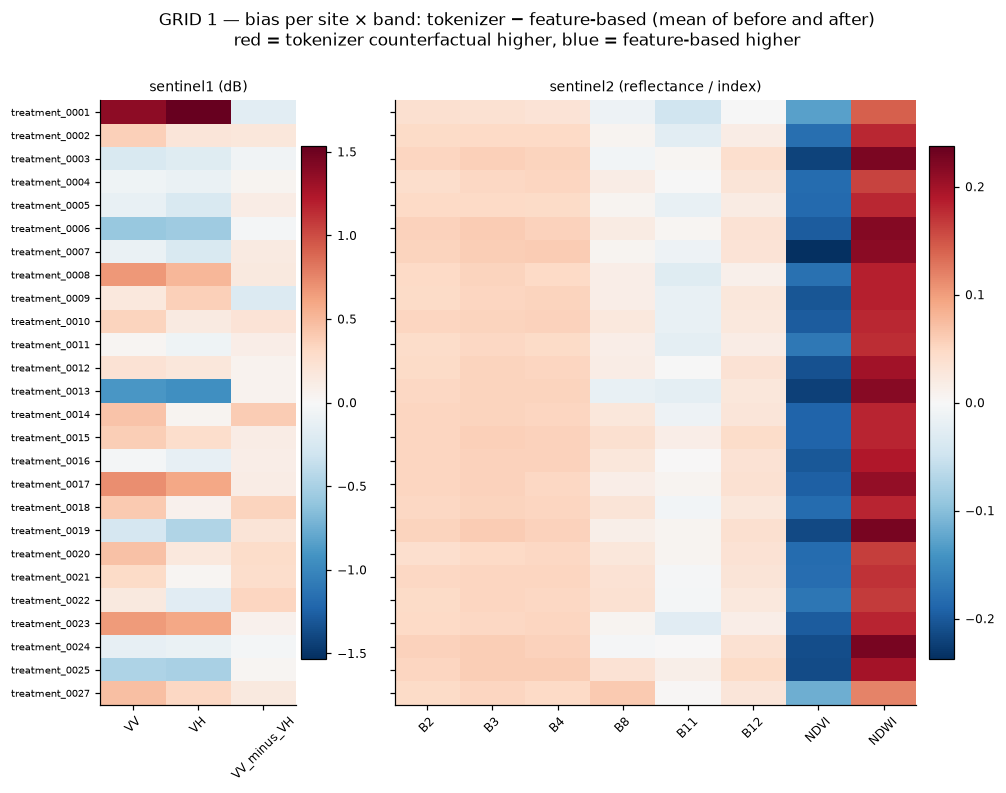

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_state_bias_heatmap.png


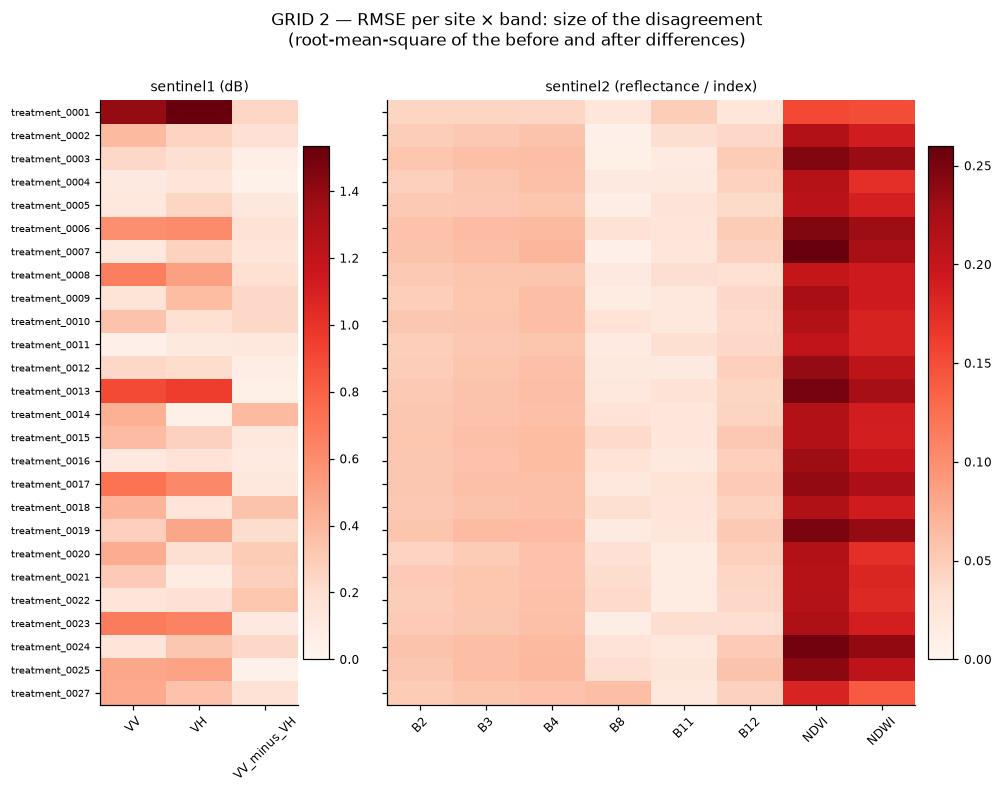

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_state_rmse_heatmap.png


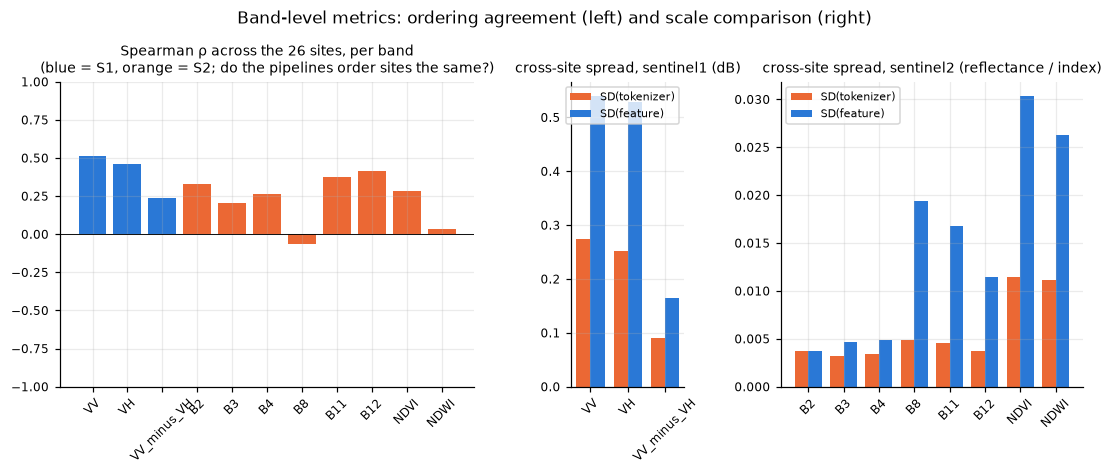

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_state_band_metrics.png


In [5]:
# Feature-based side: the collaborator's notebook-09 counterfactual, computed for
# all 26 sites by the collaborator's exact image-level procedure (notebook 09, sections 11+15): target shape = the
# treatment BEFORE chip; every other chip read with rasterio out_shape + bilinear
# resampling to that shape, masked -> NaN; mean image = np.nanmean over the 10 covariate donors;
# effect image = (treatment change) - (mean-control change); feature = per-band nanmean.
# Gated below against the collaborator's shipped treatment_0001 CSV.
import rasterio
from rasterio.enums import Resampling


def _read09(path, th=None, tw=None):
    with rasterio.open(path) as src:
        if th is None:
            d = src.read(masked=True)
        else:
            d = src.read(out_shape=(src.count, th, tw),
                         resampling=Resampling.bilinear, masked=True)
    return d.astype("float32").filled(np.nan)


feat09 = {}
for sensor in ("sentinel1", "sentinel2"):
    for tid in treatments:
        tb = _read09(chip_path(tid, sensor, "before"))
        th, tw = tb.shape[1], tb.shape[2]
        ta = _read09(chip_path(tid, sensor, "after"), th, tw)
        dl = sorted(feat_donors[tid])
        mb = np.nanmean(np.stack([_read09(chip_path(d, sensor, "before"), th, tw)
                                  for d in dl]), axis=0)
        ma = np.nanmean(np.stack([_read09(chip_path(d, sensor, "after"), th, tw)
                                  for d in dl]), axis=0)
        eff_img = (ta - tb) - (ma - mb)
        feat09[(tid, sensor)] = {
            "before": {b: float(np.nanmean(mb[i])) for i, b in enumerate(BANDS[sensor])},
            "after": {b: float(np.nanmean(ma[i])) for i, b in enumerate(BANDS[sensor])},
            "effect": {b: float(np.nanmean(eff_img[i])) for i, b in enumerate(BANDS[sensor])},
        }
    print(f"{sensor}: feature-based (notebook 09) counterfactual rebuilt for {len(treatments)} sites")

_ship = pd.read_csv(ROOT / "REAP" / "data" / "test" / "treatment_0001"
                    / "counterfactual_feature_summary.csv").set_index(["sensor", "band"])
gmax = 0.0
for sensor in ("sentinel1", "sentinel2"):
    for key, col in (("before", "mean_control_before_mean"),
                     ("after", "mean_control_after_mean"),
                     ("effect", "mean_adjusted_effect")):
        for b in BANDS[sensor]:
            gmax = max(gmax, abs(feat09[("treatment_0001", sensor)][key][b]
                                 - float(_ship.loc[(sensor, b), col])))
print(f"GATE — reproduction of the collaborator's shipped treatment_0001 outputs "
      f"(before/after/effect, all bands): max|diff| = {gmax:.2e}")
assert gmax < 1e-5, "feature-based reproduction is NOT exact — stop, do not compare"

dec_rows = []
for sensor in ("sentinel1", "sentinel2"):
    for period in ("before", "after"):
        q = torch.stack([cf_lat[(tid, sensor, period)] for tid in treatments])
        dec = decode_batch(sensor, q)
        for tid, d in zip(treatments, dec):
            f_dec = feats_from_decoded(sensor, d)
            f_feat = feat09[(tid, sensor)][period]
            for b in BANDS[sensor]:
                dec_rows.append({"treatment_site_id": tid, "sensor": sensor,
                                 "period": period, "band": b,
                                 "decoded": f_dec[b], "collab09_cf": f_feat[b],
                                 "err": f_dec[b] - f_feat[b]})
        print(f"{sensor}/{period}: 26 counterfactual latents decoded")

tok_dec = pd.DataFrame(dec_rows)
assert len(tok_dec) == 26 * 2 * (3 + 8)
tok_dec.to_csv(ED / "tok_decode_features.csv", index=False)
print("saved:", ED / "tok_decode_features.csv", tok_dec.shape)

# The 26 x 11 disagreement grids (sites x bands; band order: S1 then S2)
GRID_COLS = S1_BANDS + S2_BANDS
_e = tok_dec.set_index(["treatment_site_id", "band", "period"])["err"].unstack("period")
bias_grid = ((_e["before"] + _e["after"]) / 2).unstack("band").loc[treatments, GRID_COLS]
rmse_grid = np.sqrt((_e["before"] ** 2 + _e["after"] ** 2) / 2) \
    .unstack("band").loc[treatments, GRID_COLS]
assert bias_grid.shape == rmse_grid.shape == (26, 11)
bias_grid.to_csv(ED / "tok_state_bias_grid.csv")
rmse_grid.to_csv(ED / "tok_state_rmse_grid.csv")
print("saved:", ED / "tok_state_bias_grid.csv", "and tok_state_rmse_grid.csv")


def grid_heatmap(grid, title, cmap, diverging, fname):
    """26x11 grid as a two-panel heatmap (per-sensor color scales — units differ)."""
    fig, axs = plt.subplots(1, 2, figsize=(9.5, 7.2), sharey=True,
                            gridspec_kw={"width_ratios": [3, 8]})
    for ax, cols, name, unit in zip(
            axs, (S1_BANDS, S2_BANDS), ("sentinel1", "sentinel2"),
            ("dB", "reflectance / index")):
        v = grid[cols].values
        if diverging:
            vmax = float(np.abs(v).max()); vmin = -vmax
        else:
            vmin, vmax = 0.0, float(v.max())
        im = ax.imshow(v, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.grid(False)
        ax.set_xticks(range(len(cols)))
        ax.set_xticklabels(cols, rotation=45, fontsize=8)
        ax.set_title(f"{name} ({unit})", fontsize=9)
        fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    axs[0].set_yticks(range(len(grid)))
    axs[0].set_yticklabels(grid.index, fontsize=6.5)
    fig.suptitle(title, y=0.995, fontsize=11)
    plt.tight_layout()
    plt.savefig(ED / fname, dpi=130, bbox_inches="tight")
    plt.show()
    print("saved:", ED / fname)


grid_heatmap(bias_grid,
             "GRID 1 — bias per site × band: tokenizer − feature-based (mean of before and after)\n"
             "red = tokenizer counterfactual higher, blue = feature-based higher",
             "RdBu_r", True, "tok_state_bias_heatmap.png")
grid_heatmap(rmse_grid,
             "GRID 2 — RMSE per site × band: size of the disagreement\n"
             "(root-mean-square of the before and after differences)",
             "Reds", False, "tok_state_rmse_heatmap.png")

# Band metrics: rho as a bar plot; SD(tokenizer) vs SD(feature) as grouped bars per sensor
band_stats = []
for sensor in ("sentinel1", "sentinel2"):
    for b in BANDS[sensor]:
        sub = tok_dec.query("sensor == @sensor and band == @b")
        per = sub.groupby("period")
        band_stats.append({
            "sensor": sensor, "band": b,
            "rho": per.apply(lambda g: spearmanr(g["decoded"], g["collab09_cf"])[0]).mean(),
            "sd_ours": per["decoded"].std().mean(),
            "sd_feature": per["collab09_cf"].std().mean()})
bs = pd.DataFrame(band_stats)

fig = plt.figure(figsize=(12, 3.6))
gs = fig.add_gridspec(1, 3, width_ratios=[11, 3, 8], wspace=0.35)
ax = fig.add_subplot(gs[0])
colors = ["#2a78d6" if s == "sentinel1" else "#eb6834" for s in bs["sensor"]]
ax.bar(range(len(bs)), bs["rho"], color=colors)
ax.set_xticks(range(len(bs))); ax.set_xticklabels(bs["band"], rotation=45, fontsize=8)
ax.axhline(0, color="k", lw=0.6); ax.set_ylim(-1, 1)
ax.set_title("Spearman ρ across the 26 sites, per band\n"
             "(blue = S1, orange = S2; do the pipelines order sites the same?)",
             fontsize=9)
for ax_i, sensor, unit in ((fig.add_subplot(gs[1]), "sentinel1", "dB"),
                           (fig.add_subplot(gs[2]), "sentinel2", "reflectance / index")):
    sub = bs.query("sensor == @sensor").reset_index()
    x = np.arange(len(sub))
    ax_i.bar(x - 0.19, sub["sd_ours"], 0.38, label="SD(tokenizer)", color="#eb6834")
    ax_i.bar(x + 0.19, sub["sd_feature"], 0.38, label="SD(feature)", color="#2a78d6")
    ax_i.set_xticks(x); ax_i.set_xticklabels(sub["band"], rotation=45, fontsize=8)
    ax_i.set_title(f"cross-site spread, {sensor} ({unit})", fontsize=9)
    ax_i.legend(fontsize=7)
fig.suptitle("Band-level metrics: ordering agreement (left) and scale comparison (right)",
             y=1.06, fontsize=11)
plt.savefig(ED / "tok_state_band_metrics.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved:", ED / "tok_state_band_metrics.png")

## 5 — DiD effects: tokenizer pipeline vs feature-based pipeline (notebook 09)

**What this section compares: the final ANSWERS** — the effect each pipeline attributes
to the landslide. Two ingredients enter that section 4 never used: the before→after
differencing of the counterfactual, and the treated site's own observed change
(identical on both sides, from the original chips — no decoding on the treated side).
Effect = observed treated change − counterfactual change, computed twice: **the tokenizer route** (counterfactual change from the decoded
counterfactual) and **the feature-based route** (notebook 09's `mean_adjusted_effect`,
computed for all 26 sites by the collaborator's exact procedure and gated against the
shipped treatment_0001 value).

**The per-site scalar: effect magnitude.** Each site's effect is a vector over the
sensor's bands, and the bands have different units, so combining them into one scalar
per site requires standardization first. Following notebook 03's convention: each band's
effects are z-scored across the 26 sites — using the feature-based (notebook 09) effects as the
reference (subtract its cross-site mean, divide by its cross-site SD) — then the
magnitude is the L2 norm over the sensor's bands. One number per site per sensor per
pipeline: "how large is this site's overall effect, relative to the site population."

**The comparison, one row per sensor** (respecting the per-sensor donor caveat): the 26
magnitude pairs, read as a decomposition of the disagreement — **ρ** = ordering (do the
two pipelines rank the sites the same by overall damage? directly comparable to
notebook 03's head-to-head rank comparisons), **bias** = level (mean tokenizer − feature-based),
**SD(tokenizer) vs SD(feature)** = scale (each pipeline's spread of magnitudes across the 26
sites, side by side — a mismatch means one pipeline sees more site-to-site variation
than the other), and **RMSE** = the total (which contains the bias, so it is not read
against the SDs on its own). The grouped-bar figure below shows one site's per-band
effects from both pipelines in native units. Output: `tok_effect_magnitudes.csv`.

DiD EFFECT MAGNITUDES: tokenizer pipeline vs feature-based pipeline (notebook 09),
one scalar per site (z-scored L2 norm over the sensor's bands), 26 sites.
Column meanings — a decomposition of the disagreement:
  rho        ORDERING: do the two pipelines rank the sites the same by overall
             damage?
  bias       LEVEL: mean(tokenizer - feature-based)
  SD(tokenizer),  SCALE: each pipeline's spread of magnitudes across the 26 sites —
  SD(feature)  side by side, do they see the same amount of site-to-site variation?
  RMSE       TOTAL: root-mean-square difference (contains the bias)
  sentinel1 rho = +0.27  bias = +0.94  SD(tokenizer) = 1.12  SD(feature) = 0.83  RMSE = 1.42
  sentinel2 rho = -0.13  bias = +24.52  SD(tokenizer) = 2.74  SD(feature) = 1.24  RMSE = 24.73
saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_effect_magnitudes.csv


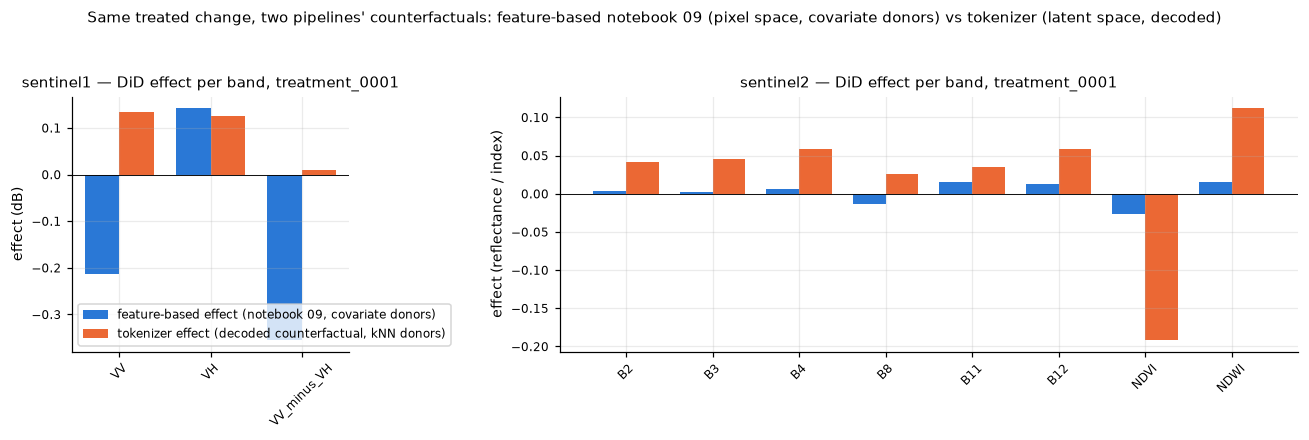

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/tok_decode_effect_comparison_treatment_0001.png


In [6]:
_feats = pd.read_csv(ROOT / "REAP" / "notebooks" / "site_band_features.csv")
_tch = _feats[_feats.period == "change"].set_index(["site_id", "sensor"])

wide = tok_dec.pivot_table(index=["treatment_site_id", "sensor", "band"],
                           columns="period", values="decoded")
eff = {}
eff["decoded"] = pd.Series(
    {(tid, sensor, b): float(_tch.loc[(tid, sensor), b])
     - (wide.loc[(tid, sensor, b), "after"] - wide.loc[(tid, sensor, b), "before"])
     for sensor in ("sentinel1", "sentinel2")
     for tid in treatments for b in BANDS[sensor]})
eff["collab09_cf"] = pd.Series(
    {(tid, sensor, b): feat09[(tid, sensor)]["effect"][b]
     for sensor in ("sentinel1", "sentinel2")
     for tid in treatments for b in BANDS[sensor]})

# Per-site effect magnitude, per sensor (notebook 03's convention): z-score each band's
# effects across the 26 sites with the feature-based (notebook 09) effects as the
# reference (subtract its cross-site mean, divide by its cross-site SD); L2 norm over
# the sensor's bands. One scalar per site per pipeline.
mag_rows = []
print("DiD EFFECT MAGNITUDES: tokenizer pipeline vs feature-based pipeline (notebook 09),")
print("one scalar per site (z-scored L2 norm over the sensor's bands), 26 sites.")
print("Column meanings — a decomposition of the disagreement:")
print("  rho        ORDERING: do the two pipelines rank the sites the same by overall")
print("             damage?")
print("  bias       LEVEL: mean(tokenizer - feature-based)")
print("  SD(tokenizer),  SCALE: each pipeline's spread of magnitudes across the 26 sites —")
print("  SD(feature)  side by side, do they see the same amount of site-to-site variation?")
print("  RMSE       TOTAL: root-mean-square difference (contains the bias)")
for sensor in ("sentinel1", "sentinel2"):
    B = BANDS[sensor]
    H = pd.DataFrame({b: [eff["collab09_cf"].loc[(t, sensor, b)] for t in treatments]
                      for b in B}, index=treatments)
    O = pd.DataFrame({b: [eff["decoded"].loc[(t, sensor, b)] for t in treatments]
                      for b in B}, index=treatments)
    mu, sd = H.mean(), H.std(ddof=1)
    mag_feat = np.sqrt((((H - mu) / sd) ** 2).sum(axis=1))
    magO = np.sqrt((((O - mu) / sd) ** 2).sum(axis=1))
    for t in treatments:
        mag_rows.append({"site": t, "sensor": sensor,
                         "magnitude_ours": float(magO[t]),
                         "magnitude_feature09": float(mag_feat[t])})
    rho = spearmanr(magO, mag_feat)[0]
    d = magO - mag_feat
    print(f"  {sensor:9s} rho = {rho:+.2f}  bias = {d.mean():+.2f}  "
          f"SD(tokenizer) = {magO.std():.2f}  SD(feature) = {mag_feat.std():.2f}  "
          f"RMSE = {float(np.sqrt((d ** 2).mean())):.2f}")

pd.DataFrame(mag_rows).to_csv(ED / "tok_effect_magnitudes.csv", index=False)
print("saved:", ED / "tok_effect_magnitudes.csv")

SITE = "treatment_0001"
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [3, 8]})
for ax, sensor in zip(axes, ("sentinel1", "sentinel2")):
    bl = BANDS[sensor]
    h = [eff["collab09_cf"].loc[(SITE, sensor, b)] for b in bl]
    d = [eff["decoded"].loc[(SITE, sensor, b)] for b in bl]
    x = np.arange(len(bl))
    ax.bar(x - 0.19, h, 0.38, label="feature-based effect (notebook 09, covariate donors)",
           color="#2a78d6")
    ax.bar(x + 0.19, d, 0.38,
           label="tokenizer effect (decoded counterfactual, kNN donors)",
           color="#eb6834")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(x); ax.set_xticklabels(bl, rotation=45, fontsize=8)
    ax.set_title(f"{sensor} — DiD effect per band, {SITE}", fontsize=10)
    ax.set_ylabel("effect (dB)" if sensor == "sentinel1" else "effect (reflectance / index)")
axes[0].legend(fontsize=8, loc="best")
fig.suptitle("Same treated change, two pipelines' counterfactuals: feature-based notebook 09 "
             "(pixel space, covariate donors) vs tokenizer (latent space, decoded)",
             y=1.04, fontsize=10)
plt.tight_layout()
out = ED / f"tok_decode_effect_comparison_{SITE}.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print("saved:", out)

## Reading (executed 2026-08-17)

**Provenance, verified in code:** the feature-based values are the collaborator's
notebook-09 counterfactual — covariate donors, image-level procedure — computed by us
for all 26 sites. Notebook 09 is a single-site test that shipped output for
treatment_0001 only, so that is the one site where a file-vs-file check is possible:
the gate matches our implementation of the procedure against the shipped CSV at
max|diff| = 1.9e-6 (float32 noise), and since the code has no special case for
treatment_0001, passing it verifies the implementation all 26 sites go through.

**The bias heatmap tells two different stories by sensor.** The S2 half is columns of
one color: NDVI solid blue (tokenizer ≈ −0.19 below feature-based at every site), NDWI
solid red (≈ +0.19 above), B2/B3/B4 uniformly pale red (≈ +0.05) — constant
calibration offsets of roughly 6–12 of the bands' signal-SDs, the S2 decoder's
reconstruction floor (6-of-12 band filling, dark-forest prior mismatch) sitting on top
of the donor difference. The S1 half is mixed colors with sign flips from site to site
(VV from −0.24 to +1.38 dB): genuinely site-specific disagreement — different donors
building different counterfactuals — not a calibration shift.

**The band-metrics figure adds ordering and scale.** Ordering: ρ is moderate at best
(S1 VV +0.51, VH +0.46; S2 between −0.06 and +0.41) — the two pipelines only partially
agree on which sites have higher counterfactual values. Scale: **SD(tokenizer) is
below SD(feature) on every band** — the decoded counterfactuals are compressed,
carrying about half of the feature-based cross-site spread on S1 (VV 0.28 vs 0.54 dB)
and as little as a quarter to a third on S2's informative bands (B8 0.005 vs 0.019,
NDVI 0.011 vs 0.030): the decoder smooths away much of the real site-to-site variation.

**The effect magnitudes (section 5), read as the decomposition.** Ordering: ρ = +0.27
(S1) / −0.13 (S2) — weak to none. Level: bias +0.94 (S1) / +24.5 (S2) — the tokenizer
pipeline reads overall damage systematically larger; on S2 the per-band offsets
survive the differencing, are divided by the feature-based bands' tiny cross-site SDs
during standardization, and accumulate in the L2 norm, so the S2 magnitude mostly
measures the decoder offset. Scale: SD(tokenizer) 1.12 vs SD(feature) 0.83 (S1), 2.74
vs 1.24 (S2) — the offset inflation also stretches the tokenizer magnitude spread.
Total: RMSE 1.42 (S1) / 24.7 (S2), both larger than the feature-based spread itself.

**What this experiment shows:** the two pipelines — feature-based (covariate donors, pixel averaging)
and tokenizer (kNN donors, latent averaging, decoded) — give substantially different
answers: constant decoder offsets and compressed variation at the state level, weak
rank agreement at the effect-magnitude level. Neither validates the other; this
comparison quantifies how much the answer depends on the pipeline — the same lesson as
the donor-overlap counts (step 2) and the rank comparisons (step 3, notebook 03) — and
placebo-rank calibration (which pipeline separates real treated sites from
pseudo-treated controls) remains the planned adjudicator. Standing caveats: the
decoder's reconstruction floor is folded into every decoded number (per-chip floor
pass deferred); the S2 tokenizer runs on 6 of its 12 expected bands; donor selection
is per sensor (joint selection is an open design discussion).